# Heart Disease UCI — Exploratory Data Analysis

Dataset: 303 patients from the Cleveland heart disease study (UCI ML Repository).
The raw target is 0–4 (0 = no disease, 1–4 = increasing severity); for the
classification task we binarize it to **presence (1) / absence (0)** of disease.

Run `python -m src.data.download` first to fetch the dataset.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.preprocess import CATEGORICAL_FEATURES, NUMERIC_FEATURES

sns.set_theme(style='whitegrid')
raw = pd.read_csv('../data/raw/heart_disease.csv')
print(raw.shape)
raw.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Missing value analysis

In [2]:
missing = raw.isna().sum()
print(missing[missing > 0])
print(f'\nRows with any missing value: {raw.isna().any(axis=1).sum()} of {len(raw)}')

ca      4
thal    2
dtype: int64

Rows with any missing value: 6 of 303


Only `ca` (4 rows) and `thal` (2 rows) have missing values — small enough to
impute (median / most-frequent) rather than drop, which the preprocessing
pipeline in `src/data/preprocess.py` does.

## Class balance

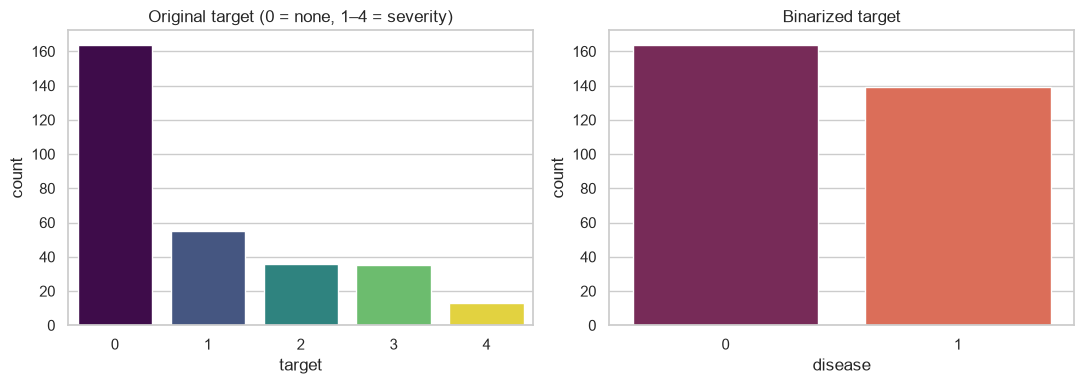

disease
0    0.541
1    0.459
Name: proportion, dtype: float64


In [3]:
df = raw.copy()
df['disease'] = (df['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=raw, x='target', ax=axes[0], hue='target', legend=False, palette='viridis')
axes[0].set_title('Original target (0 = none, 1\u20134 = severity)')
sns.countplot(data=df, x='disease', ax=axes[1], hue='disease', legend=False, palette='rocket')
axes[1].set_title('Binarized target')
plt.tight_layout()
plt.show()
print(df['disease'].value_counts(normalize=True).round(3))

The binarized classes are close to balanced (~54% / 46%), so accuracy is a
reasonable headline metric and no resampling is needed; we still track
precision/recall/F1/ROC-AUC.

## Numeric feature distributions

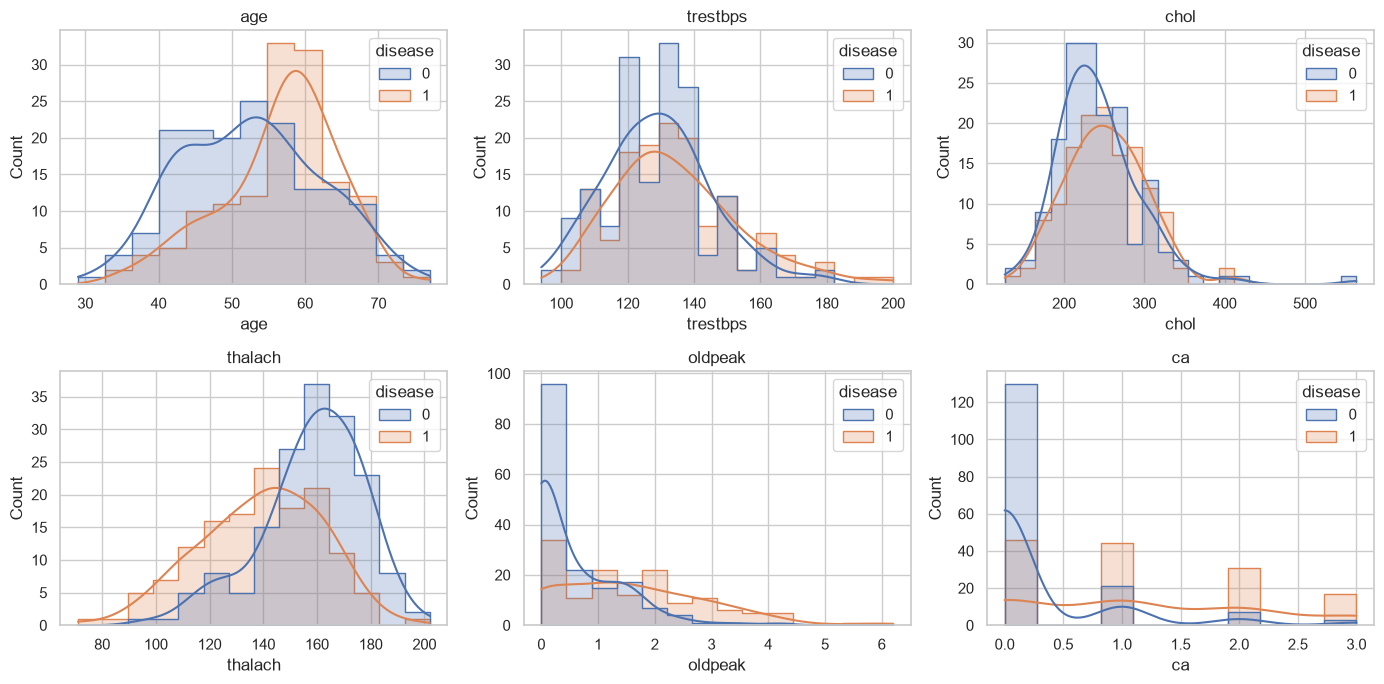

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue='disease', kde=True, ax=ax, element='step')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlation heatmap

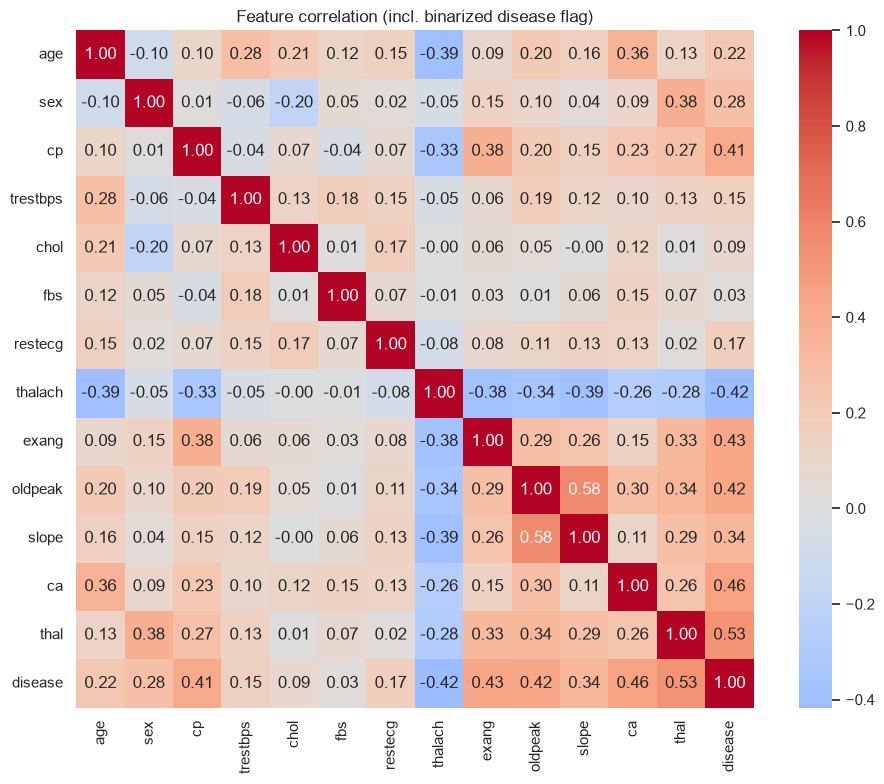

In [5]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns=['target']).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature correlation (incl. binarized disease flag)')
plt.tight_layout()
plt.show()

## Feature relationships with the target

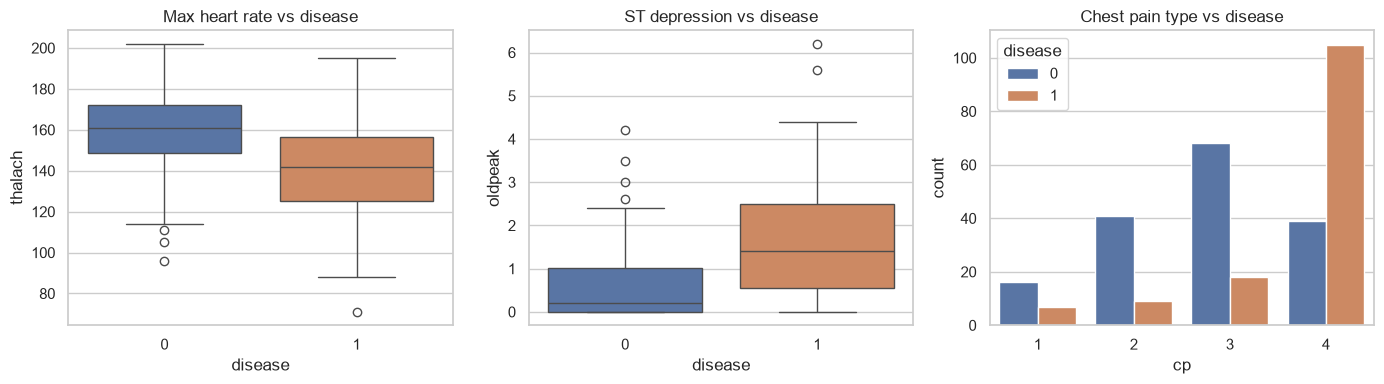

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=df, x='disease', y='thalach', hue='disease', legend=False, ax=axes[0])
axes[0].set_title('Max heart rate vs disease')
sns.boxplot(data=df, x='disease', y='oldpeak', hue='disease', legend=False, ax=axes[1])
axes[1].set_title('ST depression vs disease')
sns.countplot(data=df, x='cp', hue='disease', ax=axes[2])
axes[2].set_title('Chest pain type vs disease')
plt.tight_layout()
plt.show()

## Findings

- **Size/quality:** 303 rows, 13 features; only 6 missing values (`ca`, `thal`) → impute, don't drop.
- **Balance:** binarized target is ~54/46 — no class imbalance handling needed.
- **Strongest signals:** `thalach` (max heart rate, negative), `oldpeak`/`slope`,
  `cp` (asymptomatic chest pain type 4 dominates the disease class), `ca`, `thal`, and `exang`.
- **Weak signals:** `chol`, `fbs`, `trestbps` correlate only weakly with disease.
- **Preprocessing implications:** mixed numeric/categorical features → ColumnTransformer
  with scaling for numerics (needed by logistic regression) and one-hot encoding for
  categoricals (`cp`, `restecg`, `slope`, `thal`, ...).